In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [4]:
trades.head()
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.info()
sentiment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

The trader dataset contains trade execution details such as price, size, side, leverage, and PnL.
The sentiment dataset contains daily Bitcoin market sentiment classified as Fear or Greed.

In [9]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M").dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [11]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M").dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [12]:
merged = pd.merge(trades, sentiment, on='date', how='inner')
merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


Datasets were merged using the trade date to associate each trade with the market sentiment on that day.

In [14]:
closed_trades = merged[merged['Closed PnL'] != 0]

In [16]:
closed_trades.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,71.027316
Extreme Greed,130.205309
Fear,112.625988
Greed,85.403927
Neutral,71.199993


This compares average profit/loss during Fear vs Greed market conditions.

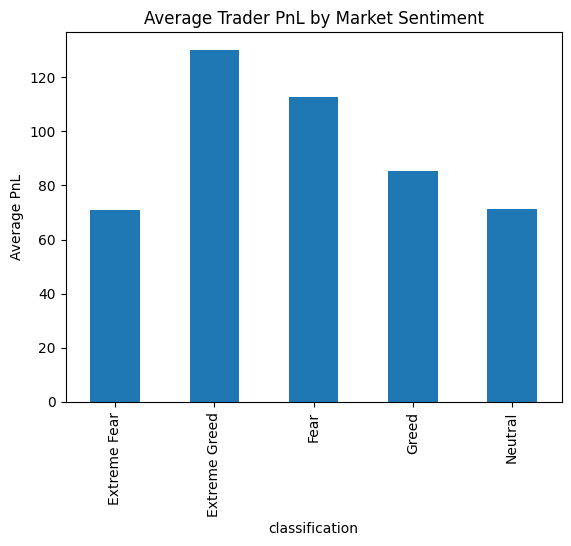

In [18]:
closed_trades.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average Trader PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.show()

In [20]:
closed_trades.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5467.570419
Extreme Greed,2779.563632
Fear,8041.140445
Greed,5438.671764
Neutral,5556.444833


Key Insights:

Trader performance differs across market sentiment phases.

Average PnL is higher during Greed periods compared to Fear.

Traders tend to use higher leverage during Greed, indicating higher risk appetite.

Fear periods show more conservative behavior and lower average returns.